# Week 2 — Data Exploration

## 1. Introduction: California Property Close Price Prediction

This notebook performs exploratory data analysis (EDA) on CRMLS sold property data.

The analysis uses 28 months of CRMLSSold data and focuses on:
- ClosePrice
- LivingArea
- Bedrooms
- Bathrooms
- LotSize

Following the project requirements, the analysis is restricted to:
- PropertyType = Residential
- PropertySubType = SingleFamilyResidence

## 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 3. Define Dataset Path

In [2]:
data_dir = Path("/Users/wy/Desktop/idx excahnge/data science/dataset/csv")

csv_files = sorted(data_dir.glob("CRMLSSold*.csv"))

print(f"Number of CSV files found: {len(csv_files)}")

for file in csv_files:
    print(file.name)

Number of CSV files found: 28
CRMLSSold202401_filled.csv
CRMLSSold202402.csv
CRMLSSold202403_filled.csv
CRMLSSold202404_filled.csv
CRMLSSold202405_filled.csv
CRMLSSold202406_filled.csv
CRMLSSold202407_filled.csv
CRMLSSold202408.csv
CRMLSSold202409.csv
CRMLSSold202410.csv
CRMLSSold202411.csv
CRMLSSold202412.csv
CRMLSSold202501_filled.csv
CRMLSSold202502.csv
CRMLSSold202503.csv
CRMLSSold202504.csv
CRMLSSold202505.csv
CRMLSSold202506.csv
CRMLSSold202507.csv
CRMLSSold202508.csv
CRMLSSold202509.csv
CRMLSSold202510.csv
CRMLSSold202511.csv
CRMLSSold202512.csv
CRMLSSold202601.csv
CRMLSSold202602.csv
CRMLSSold202603.csv
CRMLSSold202604.csv


## 4. Load All 28 Months

In [3]:
dataframes = []

for file in csv_files:
    df_month = pd.read_csv(file, low_memory=False)
    # Keep track of which file each row came from
    df_month["SourceFile"] = file.name
    dataframes.append(df_month)
print("Finished loading all files.")

Finished loading all files.


In [4]:
df = pd.concat(dataframes, ignore_index=True)
df

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,LivingArea,ListPrice,DaysOnMarket,ListOfficeName,BuyerOfficeName,CoListOfficeName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentMlsId,BuyerAgentFirstName,BuyerAgentLastName,FireplacesTotal,AssociationFeeFrequency,AboveGradeFinishedArea,ListingKeyNumeric,MLSAreaMajor,TaxAnnualAmount,CountyOrParish,MlsStatus,ElementarySchool,AttachedGarageYN,ParkingTotal,BuilderName,PropertySubType,LotSizeAcres,SubdivisionName,BuyerOfficeAOR,YearBuilt,BuyerAgencyCompensationType,StreetNumberNumeric,ListingId,BathroomsTotalInteger,City,BuyerAgencyCompensation,TaxYear,BuildingAreaTotal,BedroomsTotal,ContractStatusChangeDate,ElementarySchoolDistrict,CoBuyerAgentFirstName,PurchaseContractDate,ListingContractDate,BelowGradeFinishedArea,BusinessType,StateOrProvince,CoveredSpaces,MiddleOrJuniorSchool,FireplaceYN,Stories,HighSchool,Levels,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,SourceFile,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
0,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,Joan,Wachter,37.566106,-122.327954,1 Baldwin Avenue 411,Residential,1140.0,295000.0,777,Coldwell Banker Realty,Bay Area Senior Services,NaN,Joan Wachter,NaN,NaN,ML5090968,Scott,Withrow,NaN,Monthly,NaN,551985747,699 - Not Defined,NaN,San Mateo,Closed,NaN,False,1.0,NaN,Condominium,NaN,NaN,MLSListings,1988.0,Item1,1.0,ML81865679,2.0,San Mateo,2.5,NaN,NaN,2.0,2024-01-26,NaN,NaN,2023-11-22,2021-10-06,NaN,NaN,CA,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,False,1.0,Other,94401,6472.0,NaN,NaN,True,True,CRMLSSold202401_filled.csv,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,0.0,535486633,eabrown@lee-associates.com,2024-01-24,950.0,Elizabeth,Brown,34.529407,-117.319674,15770 Mojave Drive L,CommercialLease,NaN,808.0,901,Lee & Associates,Lee & Associates,NaN,Elizabeth Brown,NaN,NaN,HD11042,Elizabeth,Brown,NaN,NaN,NaN,535486633,NaN,NaN,San Bernardino,Closed,NaN,NaN,NaN,NaN,Retail,1.2000,NaN,HighDesert,1980.0,Item1,15770.0,538013,NaN,Victorville,3.0,NaN,NaN,NaN,2024-01-24,NaN,NaN,2024-01-24,2021-08-06,NaN,Other,CA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52320.00,NaN,NaN,NaN,NaN,92394,NaN,52320.0,NaN,False,False,CRMLSSold202401_filled.csv,NaN,NaN,NaN,NaN
2,NaN,True,NaN,NaN,NaN,75000.0,529986282,Joe@9WINWIN.com,2024-01-16,45000.0,Joseph,Piteleski,35.618009,-118.473141,0 Shadow mountain Dr.,Land,NaN,75000.0,865,Keller Williams OC Coastal Realty,Keller Williams OC Coastal Realty,NaN,Joseph Piteleski,NaN,NaN,spitejos,Joseph,Piteleski,NaN,NaN,NaN,529986282,LKIS - Lake Isabella,NaN,Kern,Closed,NaN,NaN,NaN,NaN,NaN,4.9900,NaN,OrangeCounty,NaN,Item1,0.0,OC21157144,NaN,Lake Isabella,3.0,NaN,NaN,NaN,2024-01-16,NaN,NaN,2023-12-22,2021-07-18,NaN,NaN,CA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,217364.00,NaN,False,NaN,NaN,93240,NaN,217364.0,NaN,False,False,CRMLSSold202401_filled.csv,NaN,NaN,NaN,NaN
3,NaN,True,NaN,NaN,NaN,199000.0,529618166,carolthefinder@yahoo.com,2024-01-08,141500.0,CAROL,SMITH,34.396733,-117.220954,20171 Riverview Road,Land,NaN,145000.0,830,Keller Williams Realty Phelan,Coldwell Banker Home Source,Keller Williams Realty Phelan,CAROL SMITH,DINA,VELEZ,HD12177,Stacey,Hart,NaN,NaN,NaN,529618166,NaN,NaN,San Bernardino,Closed,NaN,NaN,NaN,NaN,NaN,5.0000,NaN,HighDesert,NaN,Item1,20171.0,537165,NaN,Apple Valley,3.0,NaN,NaN,NaN,2024-01-08,NaN,NaN,2023-10-24,2021-07-14,NaN,NaN,CA,NaN,NaN,NaN,NaN,NaN,NaN,Irregular,217800.00,NaN,False,NaN,NaN,92308,NaN,217800.0,NaN,False,False,CRMLSSold202401_filled.csv,NaN,NaN,NaN,NaN
4,NaN,True,NaN,NaN,NaN,19500.0,522614340,jtavisola@tavisola.com,2024-01-17,15000.0,Jeremie,Tavisola,34.454756,-117.782248,0 Vac/Vic Avenue Z/195 Ste,Land,NaN,19500.0,805,

## 5. Initial Data Inspection

In [5]:
print("Dataset shape:")
print(df.shape)

Dataset shape:
(615707, 85)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 615707 entries, 0 to 615706
Data columns (total 85 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Flooring                      361814 non-null  str    
 1   ViewYN                        554072 non-null  object 
 2   WaterfrontYN                  339 non-null     object 
 3   BasementYN                    10159 non-null   object 
 4   PoolPrivateYN                 538866 non-null  object 
 5   OriginalListPrice             613919 non-null  float64
 6   ListingKey                    615707 non-null  int64  
 7   ListAgentEmail                614195 non-null  str    
 8   CloseDate                     615707 non-null  str    
 9   ClosePrice                    615700 non-null  float64
 10  ListAgentFirstName            612159 non-null  str    
 11  ListAgentLastName             615645 non-null  str    
 12  Latitude                      610319 non-null  float64


In [7]:
eda_columns = [
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet"
]
df[eda_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
ClosePrice,615700.0,879847.159357,5.500686e+06,0.0,55000.0,630000.0,1074000.00,9.895000e+08
LivingArea,572413.0,3429.660688,1.201789e+06,0.0,1183.0,1580.0,2151.00,9.090909e+08
BedroomsTotal,574873.0,3.081011,1.409901e+00,0.0,2.0,3.0,4.00,1.800000e+02
BathroomsTotalInteger,587332.0,2.446701,1.423724e+00,0.0,2.0,2.0,3.00,1.750000e+02
LotSizeSquareFeet,559110.0,462414.683585,2.045559e+07,0.0,5193.0,7296.0,12990.75,5.193920e+09


## 6. Filter Properties

In [8]:
df_eda = df[
    (df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")
].copy()

print(f"Original dataset rows: {len(df):,}")
print(f"Filtered dataset rows: {len(df_eda):,}")
print(f"Rows removed: {len(df) - len(df_eda):,}")

Original dataset rows: 615,707
Filtered dataset rows: 309,735
Rows removed: 305,972


## 7. Explore Required Variables

In [9]:
df_eda[eda_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
ClosePrice,309733.0,1.297553e+06,5.643293e+06,0.0,625000.0,894000.0,1430000.0,9.895000e+08
LivingArea,309569.0,2.033883e+03,1.058296e+03,0.0,1376.0,1804.0,2421.0,1.237640e+05
BedroomsTotal,309735.0,3.480905e+00,9.615222e-01,0.0,3.0,3.0,4.0,4.500000e+01
BathroomsTotalInteger,309685.0,2.616581e+00,1.199603e+00,0.0,2.0,2.0,3.0,1.750000e+02
LotSizeSquareFeet,304408.0,2.666652e+05,1.460283e+07,0.0,5663.0,7245.0,10350.0,2.087221e+09


## 8. Missing Value Check

In [10]:
missing = df_eda[eda_columns].isnull().sum()

missing_percentage = (
    df_eda[eda_columns].isnull().mean() * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_percentage
})

missing_summary

,Missing Count,Missing Percentage
ClosePrice,2,0.00
LivingArea,166,0.05
BedroomsTotal,0,0.00
BathroomsTotalInteger,50,0.02
LotSizeSquareFeet,5327,1.72


## 9. EDA Plots
### 9.1 ClosePrice Distribution

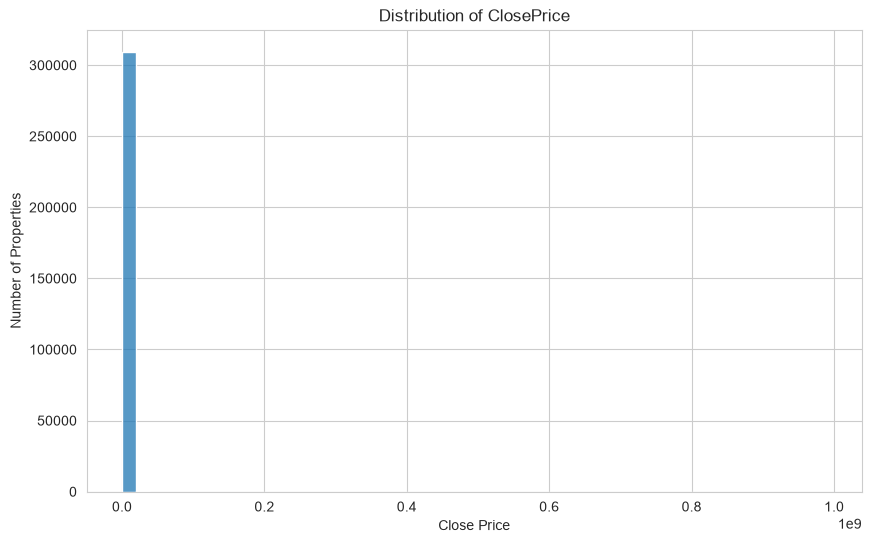

In [11]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_eda,
    x="ClosePrice",
    bins=50
)

plt.title("Distribution of ClosePrice")
plt.xlabel("Close Price")
plt.ylabel("Number of Properties")
plt.show()

check outliers

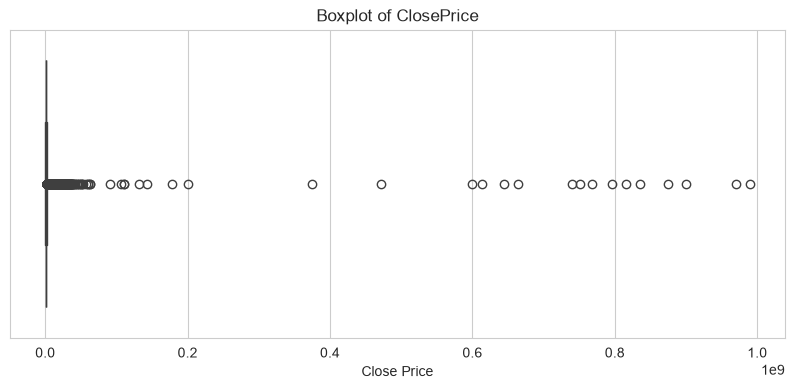

In [12]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df_eda["ClosePrice"]
)

plt.title("Boxplot of ClosePrice")
plt.xlabel("Close Price")
plt.show()

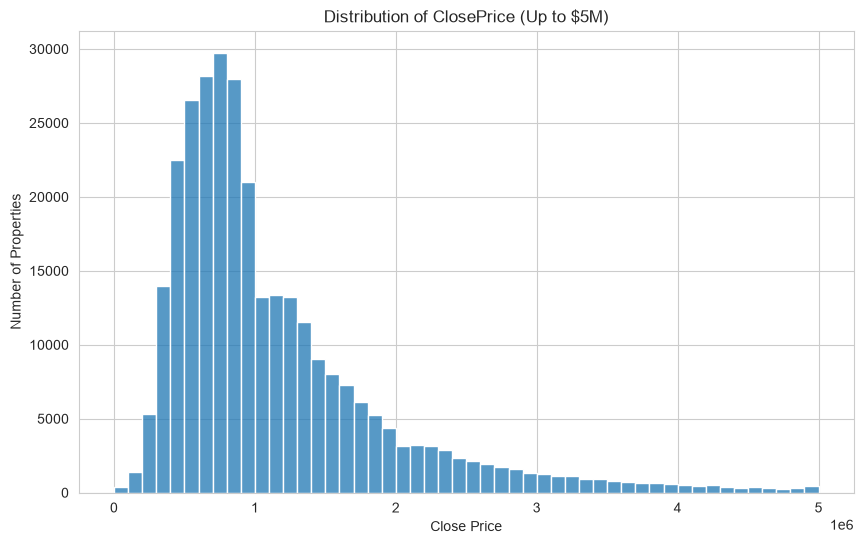

In [13]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_eda[df_eda["ClosePrice"] <= 5_000_000],
    x="ClosePrice",
    bins=50
)

plt.title("Distribution of ClosePrice (Up to $5M)")
plt.xlabel("Close Price")
plt.ylabel("Number of Properties")
plt.show()

check ClosePrice = 0

In [14]:
(df_eda["ClosePrice"] == 0).sum()

np.int64(1)

In [15]:
df_eda[df_eda["ClosePrice"] <= 0][["ClosePrice"]].head()

,ClosePrice
407174,0.0


###  9.2 LivingArea Distribution

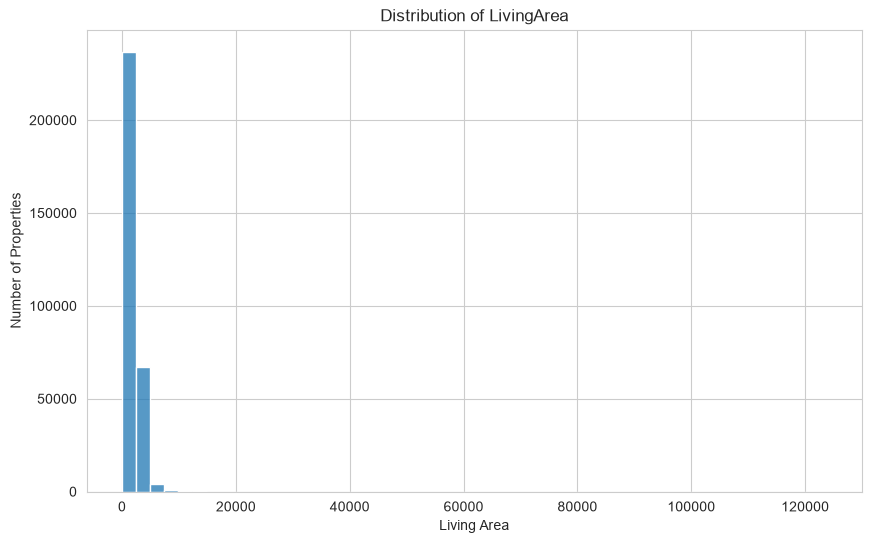

In [16]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_eda,
    x="LivingArea",
    bins=50
)

plt.title("Distribution of LivingArea")
plt.xlabel("Living Area")
plt.ylabel("Number of Properties")
plt.show()

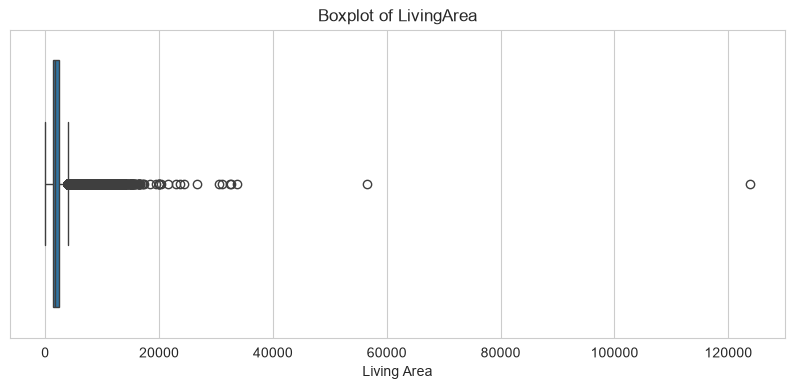

In [17]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df_eda["LivingArea"]
)

plt.title("Boxplot of LivingArea")
plt.xlabel("Living Area")
plt.show()

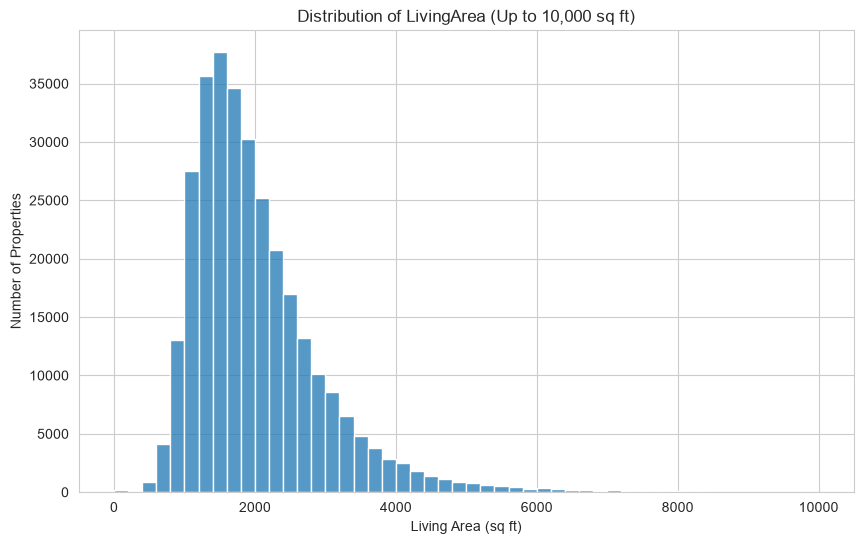

In [18]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_eda[df_eda["LivingArea"] <= 10_000],
    x="LivingArea",
    bins=50
)

plt.title("Distribution of LivingArea (Up to 10,000 sq ft)")
plt.xlabel("Living Area (sq ft)")
plt.ylabel("Number of Properties")
plt.show()

### 9.3 Bedrooms Distribution

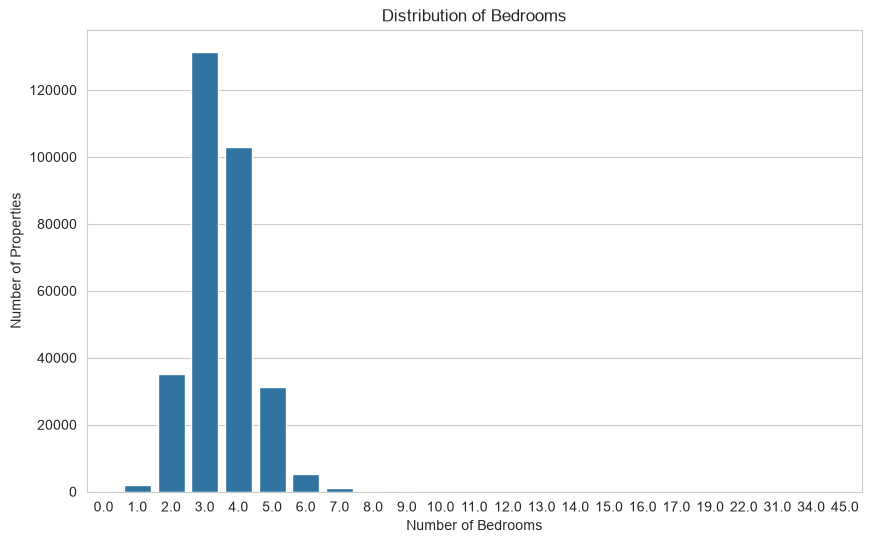

In [19]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_eda,
    x="BedroomsTotal"
)

plt.title("Distribution of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Number of Properties")
plt.show()

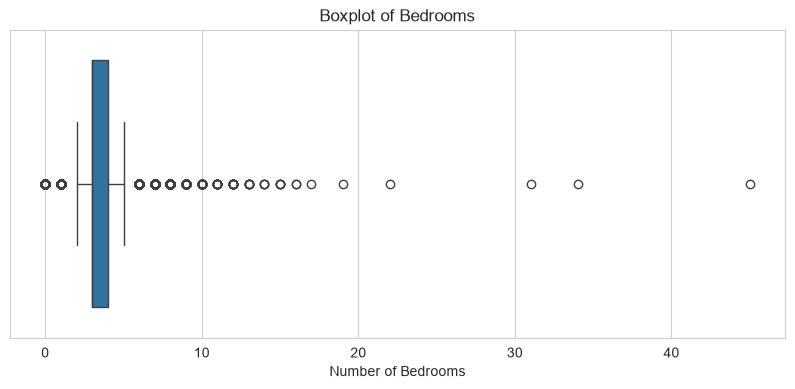

In [20]:
# Boxplot
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df_eda["BedroomsTotal"]
)

plt.title("Boxplot of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.show()

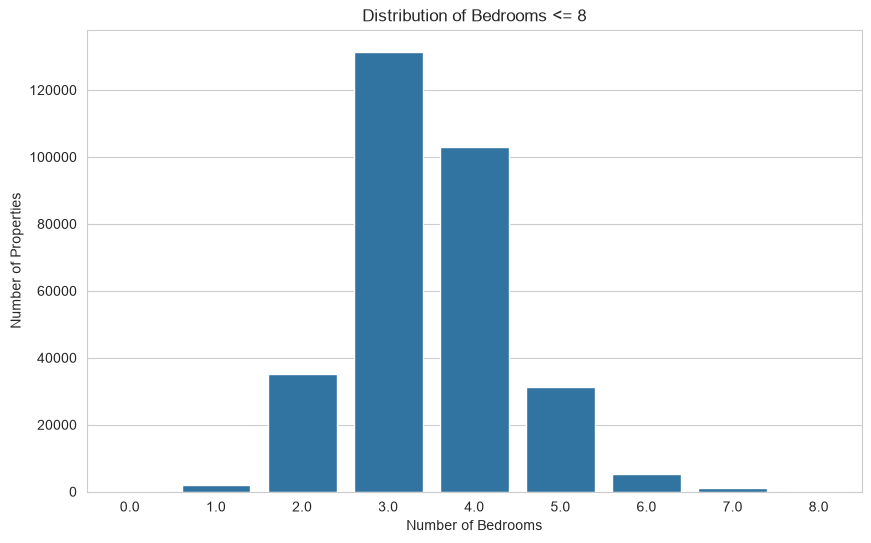

In [21]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_eda[df_eda["BedroomsTotal"] <= 8],
    x="BedroomsTotal"
)

plt.title("Distribution of Bedrooms <= 8")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Number of Properties")
plt.show()

### 9.4 Bathrooms Distribution

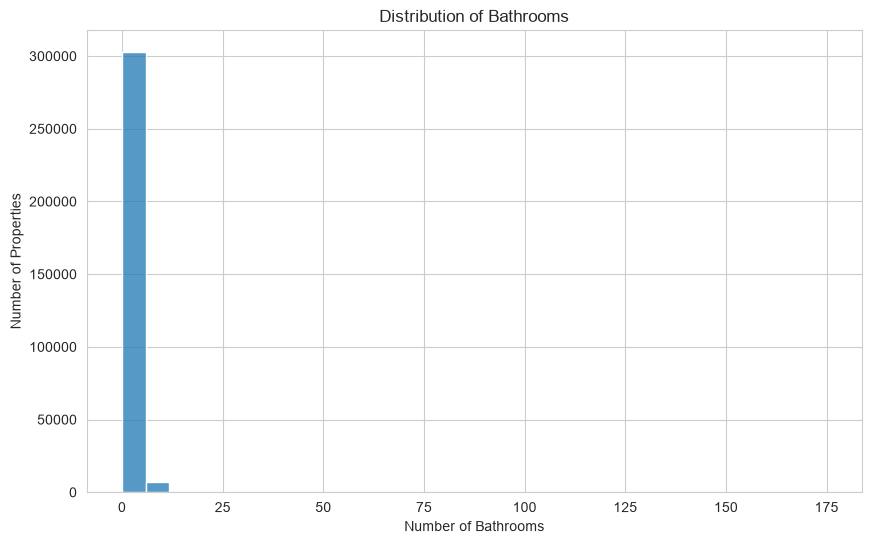

In [22]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_eda,
    x="BathroomsTotalInteger",
    bins=30
)

plt.title("Distribution of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Number of Properties")
plt.show()

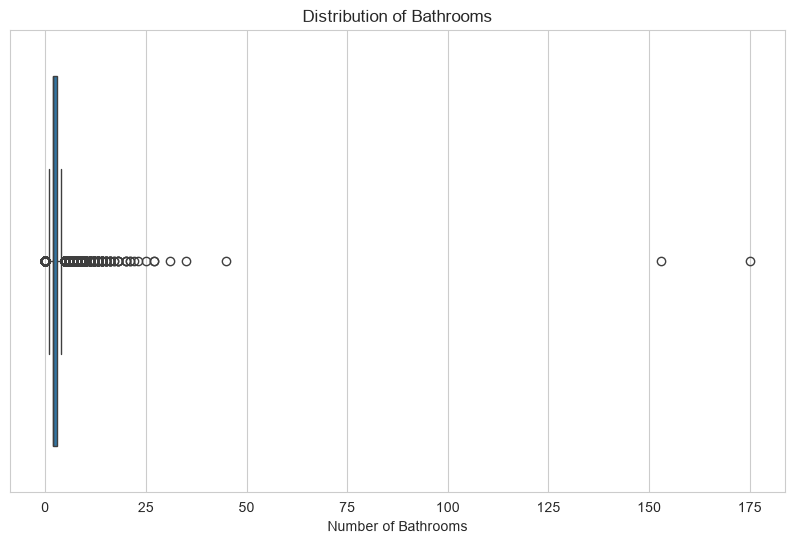

In [23]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_eda,
    x="BathroomsTotalInteger"
)

plt.title("Distribution of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.show()

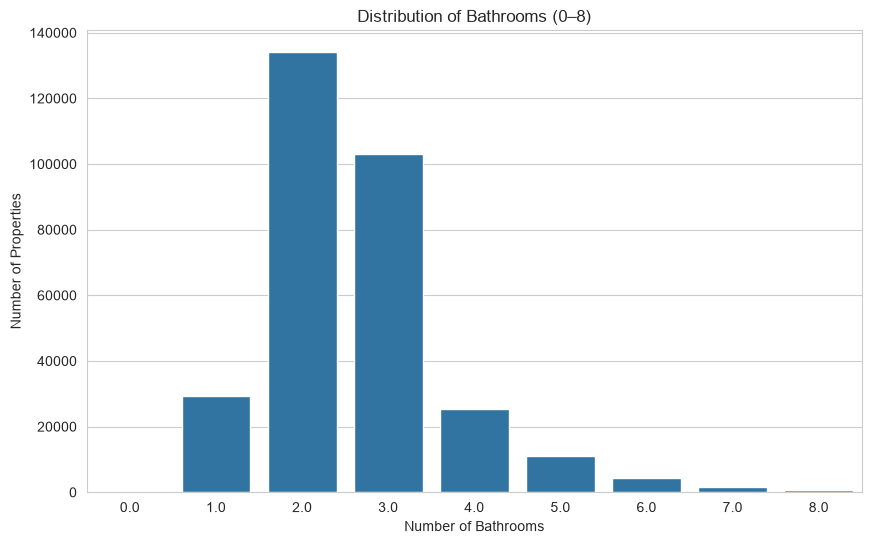

In [24]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_eda[df_eda["BathroomsTotalInteger"] <= 8],
    x="BathroomsTotalInteger"
)

plt.title("Distribution of Bathrooms (0–8)")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Number of Properties")
plt.show()

### 9.5 LotSize Distribution

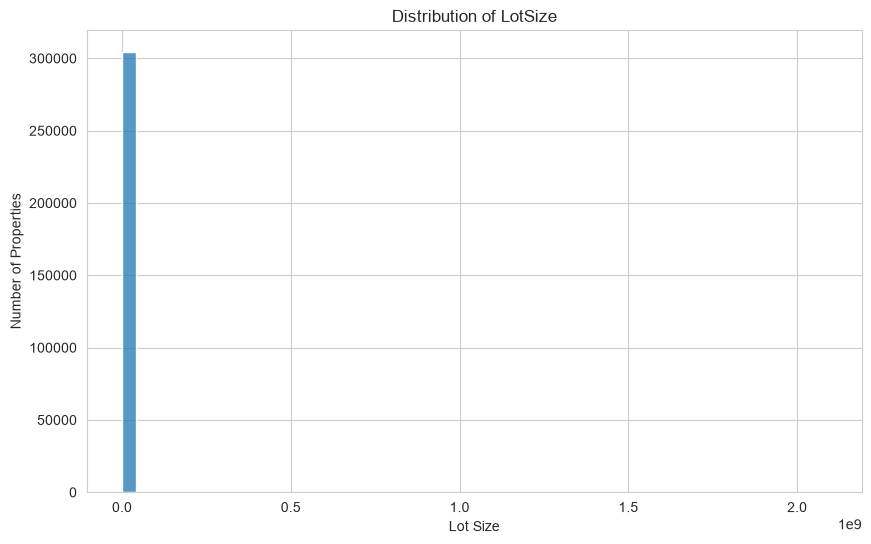

In [25]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_eda,
    x="LotSizeSquareFeet",
    bins=50
)

plt.title("Distribution of LotSize")
plt.xlabel("Lot Size")
plt.ylabel("Number of Properties")
plt.show()

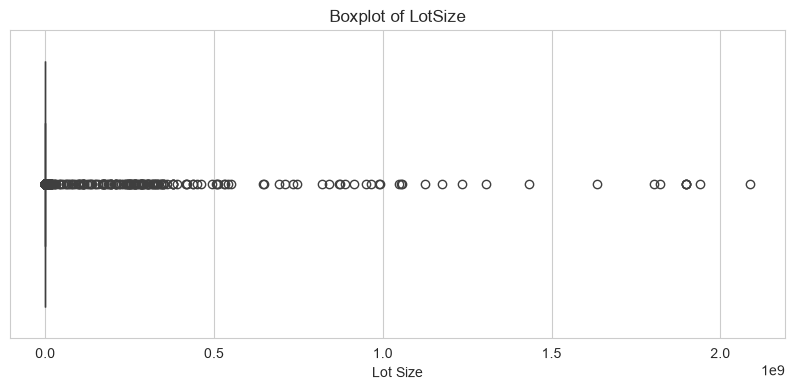

In [26]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df_eda["LotSizeSquareFeet"]
)

plt.title("Boxplot of LotSize")
plt.xlabel("Lot Size")
plt.show()

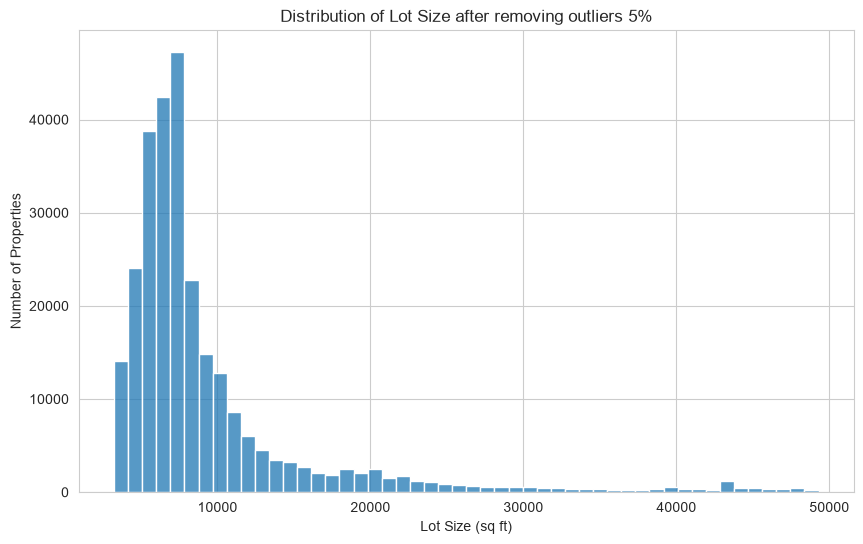

In [27]:
lot_eda = df_eda[
    df_eda["LotSizeSquareFeet"].between(
        df_eda["LotSizeSquareFeet"].quantile(0.05),
        df_eda["LotSizeSquareFeet"].quantile(0.95)
    )
]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=lot_eda,
    x="LotSizeSquareFeet",
    bins=50
)

plt.title("Distribution of Lot Size after removing outliers 5%")
plt.xlabel("Lot Size (sq ft)")
plt.ylabel("Number of Properties")
plt.show()

### 9.6 Correlation Matrix

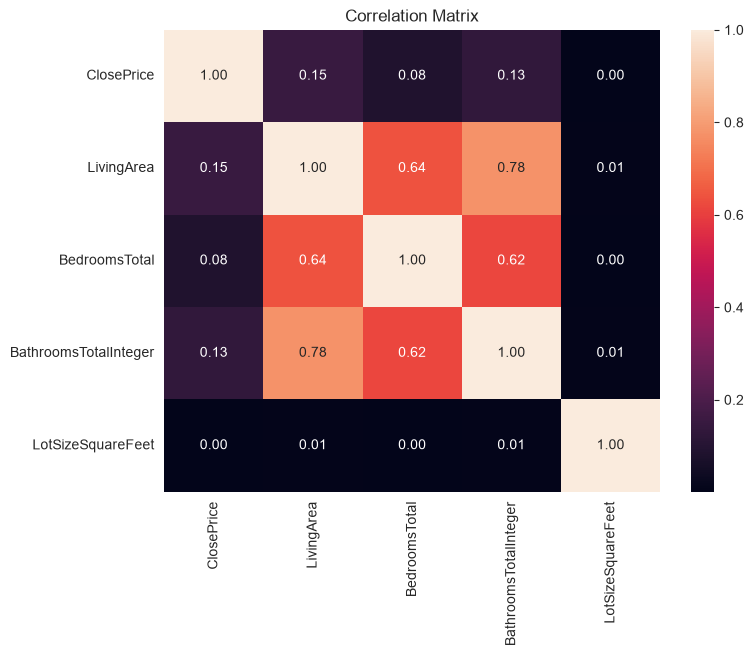

In [28]:
correlation_matrix = df_eda[eda_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

## 10. Initial EDA Findings

Based on the exploratory analysis:

1. ClosePrice shows a right-skewed distribution, with a relatively small number of high-priced properties.
2. LivingArea and LotSize also show variation and potential extreme values.
3. Bedrooms and Bathrooms have discrete distributions with some property records having relatively high counts.
4. Several variables contain missing values and/or potential outliers that will require further investigation during data preprocessing.
5. The correlation analysis shows weak linear relationships between ClosePrice and the selected property characteristics. LivingArea has the strongest correlation (0.15), followed by Bathrooms (0.13) and Bedrooms (0.08), while LotSize has almost no linear correlation. 

These findings will be considered in Week 3 when preparing the data for model training.